/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

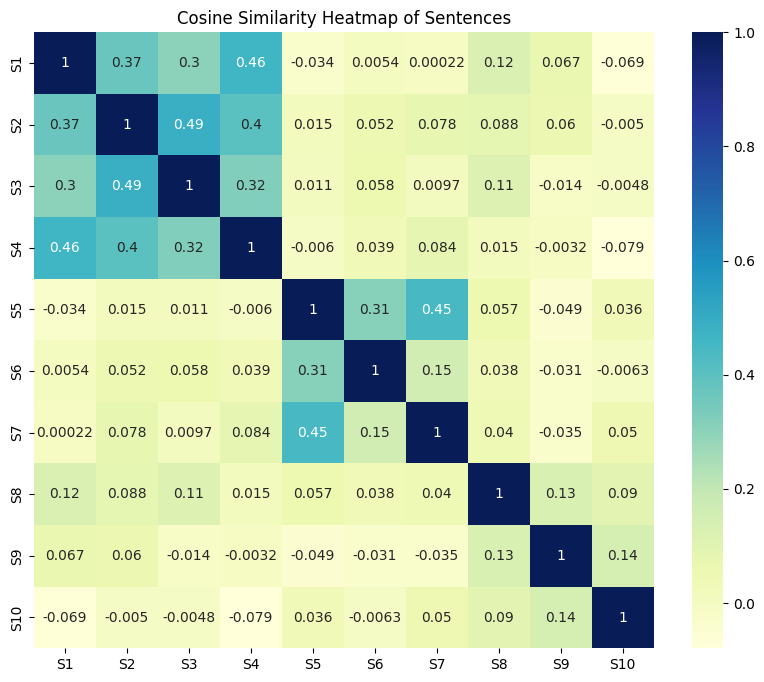


Query: 'The bowler took three wickets in one over'

Top 2 Most Similar Sentences:
Score: 0.6667 | Sentence: 'The spin bowler took a hat-trick in the final over.'
Score: 0.5295 | Sentence: 'The batsman hit a massive six over the boundary line.'


In [1]:
# Install required libraries
!pip install sentence-transformers seaborn matplotlib scikit-learn

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Initialize the model
model = SentenceTransformer('all-MiniLM-L6-v2')

# 2. Write 10 sentences across 3 topics
sentences = [
    # Cricket
    "The batsman hit a massive six over the boundary line.",
    "The spin bowler took a hat-trick in the final over.",
    "India won the cricket world cup after a thrilling match.",
    "The umpire signaled a wide ball during the powerplay.",
    # Cooking
    "Sauté the onions and garlic in olive oil until golden brown.",
    "Bake the chocolate cake at 350 degrees for forty minutes.",
    "Add a pinch of salt and black pepper to enhance the flavor.",
    # Cybersecurity
    "The firewall successfully blocked the incoming DDoS attack.",
    "Hackers exploited a zero-day vulnerability in the software.",
    "Always use two-factor authentication to secure your passwords."
]

# 3. Generate embeddings
embeddings = model.encode(sentences)

# 4. Compute 10x10 cosine similarity matrix
similarity_matrix = cosine_similarity(embeddings)

# Display Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(similarity_matrix, annot=True, cmap="YlGnBu",
            xticklabels=[f"S{i+1}" for i in range(10)],
            yticklabels=[f"S{i+1}" for i in range(10)])
plt.title("Cosine Similarity Heatmap of Sentences")
plt.show()

# 5. Querying new sentence
query = "The bowler took three wickets in one over"
query_embedding = model.encode([query])

# Calculate similarities against the original 10 sentences
query_similarities = cosine_similarity(query_embedding, embeddings)[0]

# Get top 2 indices
top_2_idx = np.argsort(query_similarities)[-2:][::-1]

print(f"\nQuery: '{query}'\n")
print("Top 2 Most Similar Sentences:")
for idx in top_2_idx:
    print(f"Score: {query_similarities[idx]:.4f} | Sentence: '{sentences[idx]}'")